# AdventureWorks Sales – 02 Exploratory Data Analysis (EDA)

## Analysis Overview

This notebook conducts comprehensive exploratory data analysis on AdventureWorks sales data across three key dimensions:

1. **Temporal Analysis** - Top 10 months by revenue with trend and seasonality patterns
2. **Product Performance** - Top 10 products with sales metrics and tiering
3. **Geographic Analysis** - Territory sales performance and order value comparisons

### Key Questions Addressed:
- Which months generate the highest revenue?
- What products drive the most sales volume and revenue?
- How do territories compare in total sales vs. average order value?
- What patterns emerge in cumulative revenue and product tiers?


In [2]:
import sqlalchemy as sa
import urllib
import pandas as pd

# Connection details
server = r"MYDELL23\SQLEXPRESS01"
database = "AdventureWorks"

conn_str = (
    "Driver={ODBC Driver 17 for SQL Server};"
    f"Server={server};"
    f"Database={database};"
    "Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(conn_str)
engine = sa.create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

def run_query(sql: str) -> pd.DataFrame:
    """Run a SQL query against AdventureWorks and return a DataFrame."""
    return pd.read_sql(sql, engine)


In [3]:
sql_monthly_top10 = """
SELECT TOP 10
    CONVERT(date, DATEFROMPARTS(YEAR(soh.OrderDate), MONTH(soh.OrderDate), 1)) AS MonthStart,
    SUM(sod.LineTotal) AS TotalSales
FROM Sales.SalesOrderHeader AS soh
JOIN Sales.SalesOrderDetail AS sod
    ON soh.SalesOrderID = sod.SalesOrderID
GROUP BY
    YEAR(soh.OrderDate),
    MONTH(soh.OrderDate)
ORDER BY TotalSales DESC;
"""

df_monthly_top10 = run_query(sql_monthly_top10)
df_monthly_top10.head()


,MonthStart,TotalSales
0,2014-03-01,7.217531e+06
1,2014-05-01,5.366675e+06
2,2013-06-01,5.081069e+06
3,2013-07-01,4.896354e+06
4,2013-10-01,4.795813e+06


In [4]:
sql_top_products = """
SELECT TOP 10
    p.Name AS ProductName,
    SUM(sod.LineTotal) AS TotalSales,
    SUM(sod.OrderQty) AS TotalQuantity,
    COUNT(DISTINCT sod.SalesOrderID) AS OrderCount
FROM Sales.SalesOrderDetail AS sod
JOIN Production.Product AS p
    ON sod.ProductID = p.ProductID
GROUP BY
    p.Name
ORDER BY TotalSales DESC;
"""
df_top_products = run_query(sql_top_products)
df_top_products.head()


,ProductName,TotalSales,TotalQuantity,OrderCount
0,"Mountain-200 Black, 38",4.400593e+06,2977,1252
1,"Mountain-200 Black, 42",4.009495e+06,2664,1177
2,"Mountain-200 Silver, 38",3.693678e+06,2394,1094
3,"Mountain-200 Silver, 42",3.438479e+06,2234,1040
4,"Mountain-200 Silver, 46",3.434257e+06,2216,1054


In [5]:
sql_territory_sales = """
SELECT TOP 10
    st.Name AS TerritoryName,
    SUM(soh.SubTotal) AS TotalSales,
    COUNT(DISTINCT soh.SalesOrderID) AS OrderCount,
    AVG(soh.SubTotal) AS AvgOrderValue
FROM Sales.SalesOrderHeader AS soh
JOIN Sales.SalesTerritory AS st
    ON soh.TerritoryID = st.TerritoryID
GROUP BY
    st.Name
ORDER BY TotalSales DESC;
"""

df_territory_sales = run_query(sql_territory_sales)
df_territory_sales.head()


,TerritoryName,TotalSales,OrderCount,AvgOrderValue
0,Southwest,2.418461e+07,6224,3885.7020
1,Canada,1.635577e+07,4067,4021.5811
2,Northwest,1.608494e+07,4594,3501.2935
3,Australia,1.065534e+07,6843,1557.1147
4,Central,7.909009e+06,385,20542.8805


## 1. Data Loading and Connection Setup

Loading pre-aggregated sales data from SQL Server using three optimized queries:
- `df_monthly_top10`: Top 10 revenue months
- `df_top_products`: Top 10 products by total sales
- `df_territory_sales`: Top 10 territories by revenue

All queries use appropriate JOINs and aggregations to minimize data transfer.

## Data overview

Quick structural checks for the three core sales DataFrames used in this EDA:
- `df_monthly_top10`: top 10 months by total sales.
- `df_top_products`: top 10 products by sales, quantity, and order count.
- `df_territory_sales`: top 10 territories by total sales and average order value.


In [6]:
print("df_monthly_top10:", df_monthly_top10.shape)
display(df_monthly_top10.head(10))

print("\ndf_top_products:", df_top_products.shape)
display(df_top_products.head(10))

print("\ndf_territory_sales:", df_territory_sales.shape)
display(df_territory_sales.head(10))


df_monthly_top10: (10, 2)


,MonthStart,TotalSales
0,2014-03-01,7.217531e+06
1,2014-05-01,5.366675e+06
2,2013-06-01,5.081069e+06
3,2013-07-01,4.896354e+06
4,2013-10-01,4.795813e+06
5,2011-10-01,4.588762e+06
6,2013-09-01,4.532909e+06
7,2014-01-01,4.289818e+06
8,2012-06-01,4.099354e+06
9,2013-12-01,4.075487e+06



df_top_products: (10, 4)


,ProductName,TotalSales,TotalQuantity,OrderCount
0,"Mountain-200 Black, 38",4.400593e+06,2977,1252
1,"Mountain-200 Black, 42",4.009495e+06,2664,1177
2,"Mountain-200 Silver, 38",3.693678e+06,2394,1094
3,"Mountain-200 Silver, 42",3.438479e+06,2234,1040
4,"Mountain-200 Silver, 46",3.434257e+06,2216,1054
5,"Mountain-200 Black, 46",3.309673e+06,2111,1059
6,"Road-250 Black, 44",2.516857e+06,1642,705
7,"Road-250 Black, 48",2.347656e+06,1498,712
8,"Road-250 Black, 52",2.012448e+06,1245,667
9,"Road-150 Red, 56",1.847819e+06,664,475



df_territory_sales: (10, 4)


,TerritoryName,TotalSales,OrderCount,AvgOrderValue
0,Southwest,2.418461e+07,6224,3885.7020
1,Canada,1.635577e+07,4067,4021.5811
2,Northwest,1.608494e+07,4594,3501.2935
3,Australia,1.065534e+07,6843,1557.1147
4,Central,7.909009e+06,385,20542.8805
5,Southeast,7.879655e+06,486,16213.2820
6,United Kingdom,7.670721e+06,3219,2382.9515
7,France,7.251556e+06,2672,2713.9055
8,Northeast,6.939374e+06,352,19714.1320
9,Germany,4.915408e+06,2623,1873.9640


## Structural and summary checks

Check dtypes, basic statistics, and missing values for each DataFrame to confirm the data is clean and numeric columns behave as expected.

## 2. Feature Engineering

### Product Analysis Enhancement
Creating derived metrics to better understand product performance:
- **RevenuePerUnit**: Average price per item sold (identifies premium products)
- **RevenuePerOrder**: Average revenue per order (measures order size)
- **RevenueShare**: Each product's contribution to total top-10 revenue
- **SalesTier**: Categorizes products into Low/Medium/High tiers using quantile-based bucketing

### Territory Analysis Enhancement
Adding ranking and comparison metrics:
- **RevenuePerOrder**: Calculated average (validates SQL-computed AvgOrderValue)
- **SalesRank**: Territories ranked by total revenue (1 = highest)
- **AvgOrderValueRank**: Territories ranked by order value (identifies premium markets)

### Temporal Analysis Enhancement
Time-series metrics for trend analysis:
- **CumulativeSales**: Running total of sales across sorted months
- **CumulativeShare**: Percentage of total revenue accumulated
- **Rolling3Sales**: 3-month moving average to smooth volatility

In [7]:
def summarize_df(df, name):
    print(f"=== {name} ===")
    display(df.info())
    display(df.describe(include="all"))
    print("\nMissing values:")
    display(df.isna().sum())
    print("\n" + "-" * 60 + "\n")

summarize_df(df_monthly_top10, "df_monthly_top10")
summarize_df(df_top_products, "df_top_products")
summarize_df(df_territory_sales, "df_territory_sales")


=== df_monthly_top10 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MonthStart  10 non-null     object 
 1   TotalSales  10 non-null     float64
dtypes: float64(1), object(1)
memory usage: 292.0+ bytes


None

,MonthStart,TotalSales
count,10,1.000000e+01
unique,10,NaN
top,2014-03-01,NaN
freq,1,NaN
mean,NaN,4.894377e+06
std,NaN,9.163258e+05
min,NaN,4.075487e+06
25%,NaN,4.350591e+06
50%,NaN,4.692288e+06
75%,NaN,5.034890e+06



Missing values:


MonthStart    0
TotalSales    0
dtype: int64

...

None

,TerritoryName,TotalSales,OrderCount,AvgOrderValue
count,10,1.000000e+01,10.000000,10.000000
unique,10,NaN,NaN,NaN
top,Southwest,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,1.098464e+07,3146.500000,7640.680680
std,NaN,6.022439e+06,2335.606666,7833.250917
min,NaN,4.915408e+06,352.000000,1557.114700
25%,NaN,7.356347e+06,1020.250000,2465.690000
50%,NaN,7.894332e+06,2945.500000,3693.497750
75%,NaN,1.472754e+07,4462.250000,13165.356775



Missing values:


TerritoryName    0
TotalSales       0
OrderCount       0
AvgOrderValue    0
dtype: int64


------------------------------------------------------------



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)


In [9]:
df_top_products.head()

,ProductName,TotalSales,TotalQuantity,OrderCount
0,"Mountain-200 Black, 38","4,400,592.80",2977,1252
1,"Mountain-200 Black, 42","4,009,494.76",2664,1177
2,"Mountain-200 Silver, 38","3,693,678.03",2394,1094
3,"Mountain-200 Silver, 42","3,438,478.86",2234,1040
4,"Mountain-200 Silver, 46","3,434,256.94",2216,1054


In [10]:
df_top_products = df_top_products.copy()

df_top_products["RevenuePerUnit"] = df_top_products["TotalSales"] / df_top_products["TotalQuantity"]
df_top_products["RevenuePerOrder"] = df_top_products["TotalSales"] / df_top_products["OrderCount"]

total_revenue = df_top_products["TotalSales"].sum()
df_top_products["RevenueShare"] = df_top_products["TotalSales"] / total_revenue

df_top_products.head()


,ProductName,TotalSales,TotalQuantity,OrderCount,RevenuePerUnit,RevenuePerOrder,RevenueShare
0,"Mountain-200 Black, 38","4,400,592.80",2977,1252,"1,478.20","3,514.85",0.14
1,"Mountain-200 Black, 42","4,009,494.76",2664,1177,"1,505.07","3,406.54",0.13
2,"Mountain-200 Silver, 38","3,693,678.03",2394,1094,"1,542.89","3,376.31",0.12
3,"Mountain-200 Silver, 42","3,438,478.86",2234,1040,"1,539.16","3,306.23",0.11
4,"Mountain-200 Silver, 46","3,434,256.94",2216,1054,"1,549.75","3,258.31",0.11


In [11]:
import pandas as pd

df_top_products["SalesTier"] = pd.qcut(
    df_top_products["TotalSales"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df_top_products[["ProductName", "TotalSales", "SalesTier"]]


,ProductName,TotalSales,SalesTier
0,"Mountain-200 Black, 38","4,400,592.80",High
1,"Mountain-200 Black, 42","4,009,494.76",High
2,"Mountain-200 Silver, 38","3,693,678.03",High
3,"Mountain-200 Silver, 42","3,438,478.86",Medium
4,"Mountain-200 Silver, 46","3,434,256.94",Medium
5,"Mountain-200 Black, 46","3,309,673.22",Medium
6,"Road-250 Black, 44","2,516,857.31",Low
7,"Road-250 Black, 48","2,347,655.95",Low
8,"Road-250 Black, 52","2,012,447.77",Low
9,"Road-150 Red, 56","1,847,818.63",Low


In [12]:
tier_summary = (
    df_top_products
    .groupby("SalesTier", observed=True)
    .agg(
        Products=("ProductName", "count"),
        TotalSales=("TotalSales", "sum"),
        AvgRevenuePerUnit=("RevenuePerUnit", "mean"),
        AvgRevenuePerOrder=("RevenuePerOrder", "mean"),
        RevenueShare=("RevenueShare", "sum"),
    )
    .sort_values("TotalSales", ascending=False)
)

tier_summary


,Products,TotalSales,AvgRevenuePerUnit,AvgRevenuePerOrder,RevenueShare
SalesTier,,,,,
High,3,"12,103,765.59","1,508.72","3,432.56",0.39
Medium,3,"10,182,409.02","1,552.25","3,229.94",0.33
Low,4,"8,724,779.67","1,874.82","3,443.65",0.28


### Product tier summary

This table compares Low/Medium/High sales tiers by count of products, total revenue, and average revenue per unit/order. It highlights which tier contributes most to overall sales.

In [13]:
df_territory_sales.head()

,TerritoryName,TotalSales,OrderCount,AvgOrderValue
0,Southwest,"24,184,609.60",6224,"3,885.70"
1,Canada,"16,355,770.46",4067,"4,021.58"
2,Northwest,"16,084,942.55",4594,"3,501.29"
3,Australia,"10,655,335.96",6843,"1,557.11"
4,Central,"7,909,009.01",385,"20,542.88"


In [14]:
df_territory_sales = df_territory_sales.copy()

# Revenue per order (sanity check vs AvgOrderValue from SQL)
df_territory_sales["RevenuePerOrder"] = (
    df_territory_sales["TotalSales"] / df_territory_sales["OrderCount"]
)

# Rank territories by TotalSales (1 = highest)
df_territory_sales["SalesRank"] = df_territory_sales["TotalSales"].rank(
    method="dense", ascending=False
)

# Rank territories by AvgOrderValue (1 = highest)
df_territory_sales["AvgOrderValueRank"] = df_territory_sales["AvgOrderValue"].rank(
    method="dense", ascending=False
)

df_territory_sales.head(10)


,TerritoryName,TotalSales,OrderCount,AvgOrderValue,RevenuePerOrder,SalesRank,AvgOrderValueRank
0,Southwest,"24,184,609.60",6224,"3,885.70","3,885.70",1.00,5.00
1,Canada,"16,355,770.46",4067,"4,021.58","4,021.58",2.00,4.00
2,Northwest,"16,084,942.55",4594,"3,501.29","3,501.29",3.00,6.00
3,Australia,"10,655,335.96",6843,"1,557.11","1,557.11",4.00,10.00
4,Central,"7,909,009.01",385,"20,542.88","20,542.88",5.00,1.00
5,Southeast,"7,879,655.07",486,"16,213.28","16,213.28",6.00,3.00
6,United Kingdom,"7,670,721.04",3219,"2,382.95","2,382.95",7.00,8.00
7,France,"7,251,555.65",2672,"2,713.91","2,713.91",8.00,7.00
8,Northeast,"6,939,374.48",352,"19,714.13","19,714.13",9.00,2.00
9,Germany,"4,915,407.60",2623,"1,873.96","1,873.96",10.00,9.00


In [15]:
territory_rank_view = (
    df_territory_sales[
        [
            "TerritoryName",
            "TotalSales",
            "OrderCount",
            "AvgOrderValue",
            "RevenuePerOrder",
            "SalesRank",
            "AvgOrderValueRank",
        ]
    ]
    .sort_values("SalesRank")
    .reset_index(drop=True)
)

territory_rank_view


,TerritoryName,TotalSales,OrderCount,AvgOrderValue,RevenuePerOrder,SalesRank,AvgOrderValueRank
0,Southwest,"24,184,609.60",6224,"3,885.70","3,885.70",1.00,5.00
1,Canada,"16,355,770.46",4067,"4,021.58","4,021.58",2.00,4.00
2,Northwest,"16,084,942.55",4594,"3,501.29","3,501.29",3.00,6.00
3,Australia,"10,655,335.96",6843,"1,557.11","1,557.11",4.00,10.00
4,Central,"7,909,009.01",385,"20,542.88","20,542.88",5.00,1.00
5,Southeast,"7,879,655.07",486,"16,213.28","16,213.28",6.00,3.00
6,United Kingdom,"7,670,721.04",3219,"2,382.95","2,382.95",7.00,8.00
7,France,"7,251,555.65",2672,"2,713.91","2,713.91",8.00,7.00
8,Northeast,"6,939,374.48",352,"19,714.13","19,714.13",9.00,2.00
9,Germany,"4,915,407.60",2623,"1,873.96","1,873.96",10.00,9.00


In [16]:
df_monthly_top10.head()

,MonthStart,TotalSales
0,2014-03-01,"7,217,531.09"
1,2014-05-01,"5,366,674.97"
2,2013-06-01,"5,081,069.13"
3,2013-07-01,"4,896,353.74"
4,2013-10-01,"4,795,813.29"


In [17]:
df_monthly_top10 = df_monthly_top10.copy()

# Ensure sorted by MonthStart
df_monthly_top10 = df_monthly_top10.sort_values("MonthStart")

# Cumulative sales
df_monthly_top10["CumulativeSales"] = df_monthly_top10["TotalSales"].cumsum()

# Cumulative revenue share
total_monthly_sales = df_monthly_top10["TotalSales"].sum()
df_monthly_top10["CumulativeShare"] = df_monthly_top10["CumulativeSales"] / total_monthly_sales

# 3-period rolling mean of sales
df_monthly_top10["Rolling3Sales"] = (
    df_monthly_top10["TotalSales"].rolling(window=3, min_periods=1).mean()
)

df_monthly_top10


,MonthStart,TotalSales,CumulativeSales,CumulativeShare,Rolling3Sales
5,2011-10-01,"4,588,761.82","4,588,761.82",0.09,"4,588,761.82"
8,2012-06-01,"4,099,354.36","8,688,116.17",0.18,"4,344,058.09"
2,2013-06-01,"5,081,069.13","13,769,185.30",0.28,"4,589,728.43"
3,2013-07-01,"4,896,353.74","18,665,539.04",0.38,"4,692,259.08"
6,2013-09-01,"4,532,908.71","23,198,447.75",0.47,"4,836,777.19"
4,2013-10-01,"4,795,813.29","27,994,261.04",0.57,"4,741,691.91"
9,2013-12-01,"4,075,486.63","32,069,747.66",0.66,"4,468,069.54"
7,2014-01-01,"4,289,817.95","36,359,565.61",0.74,"4,387,039.29"
0,2014-03-01,"7,217,531.09","43,577,096.71",0.89,"5,194,278.56"
1,2014-05-01,"5,366,674.97","48,943,771.68",1.00,"5,624,674.67"


## 3. Visualizations and Insights

### 3.1 Monthly Sales Trends

### Monthly sales – cumulative and rolling view

This section calculates cumulative sales and cumulative revenue share across the top 10 months to see how quickly revenue accumulates over time. It also adds a 3‑month rolling average of monthly sales to smooth short‑term spikes and highlight the underlying trend.


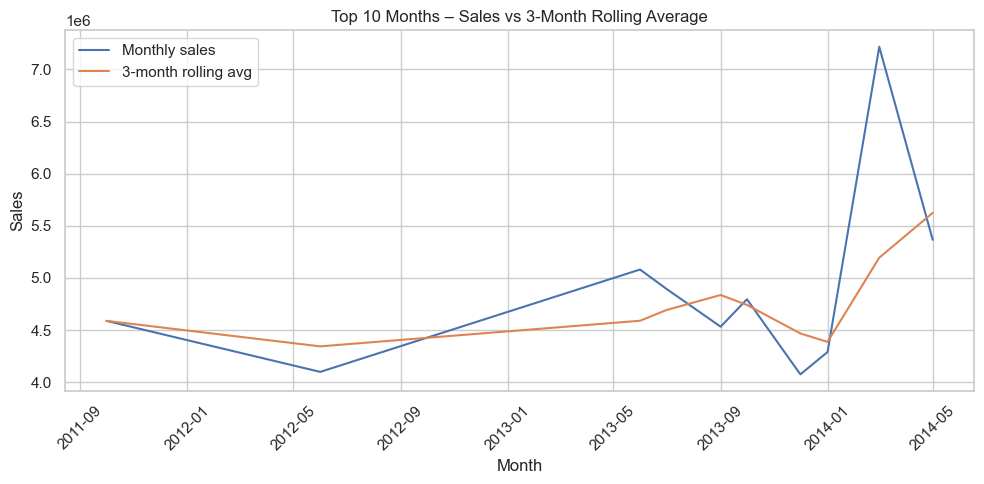

In [18]:
fig, ax = plt.subplots()

ax.plot(df_monthly_top10["MonthStart"], df_monthly_top10["TotalSales"], label="Monthly sales")
ax.plot(df_monthly_top10["MonthStart"], df_monthly_top10["Rolling3Sales"], label="3-month rolling avg")

ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.set_title("Top 10 Months – Sales vs 3-Month Rolling Average")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Top 10 months – trend vs volatility

This line chart compares actual monthly sales (blue) with a 3‑month rolling average (orange). The rolling line smooths short‑term spikes and dips, making it easier to see the underlying upward trend and how extreme certain peak months are relative to recent history.

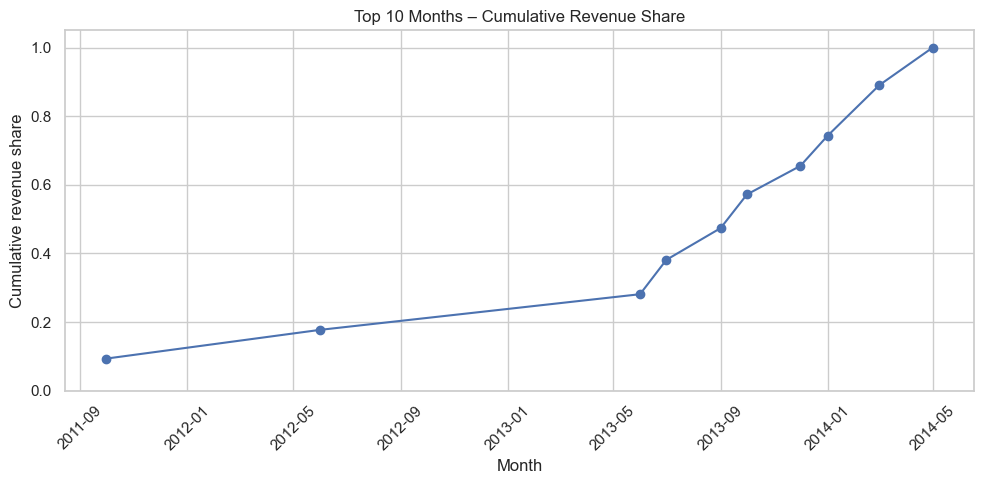

In [19]:
fig, ax = plt.subplots()

ax.plot(
    df_monthly_top10["MonthStart"],
    df_monthly_top10["CumulativeShare"],
    marker="o"
)

ax.set_xlabel("Month")
ax.set_ylabel("Cumulative revenue share")
ax.set_title("Top 10 Months – Cumulative Revenue Share")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Top 10 months – cumulative revenue share

This chart shows how quickly revenue accumulates across the top 10 months. The curve rises slowly at first, then increases sharply in late 2013–2014, indicating that a few recent peak months contribute a disproportionately large share of total sales among these top months.

In [20]:
# Correlation between key numeric columns
product_corr = df_top_products[["TotalSales", "TotalQuantity", "OrderCount"]].corr()
product_corr

,TotalSales,TotalQuantity,OrderCount
TotalSales,1.00,0.98,0.98
TotalQuantity,0.98,1.00,0.98
OrderCount,0.98,0.98,1.00


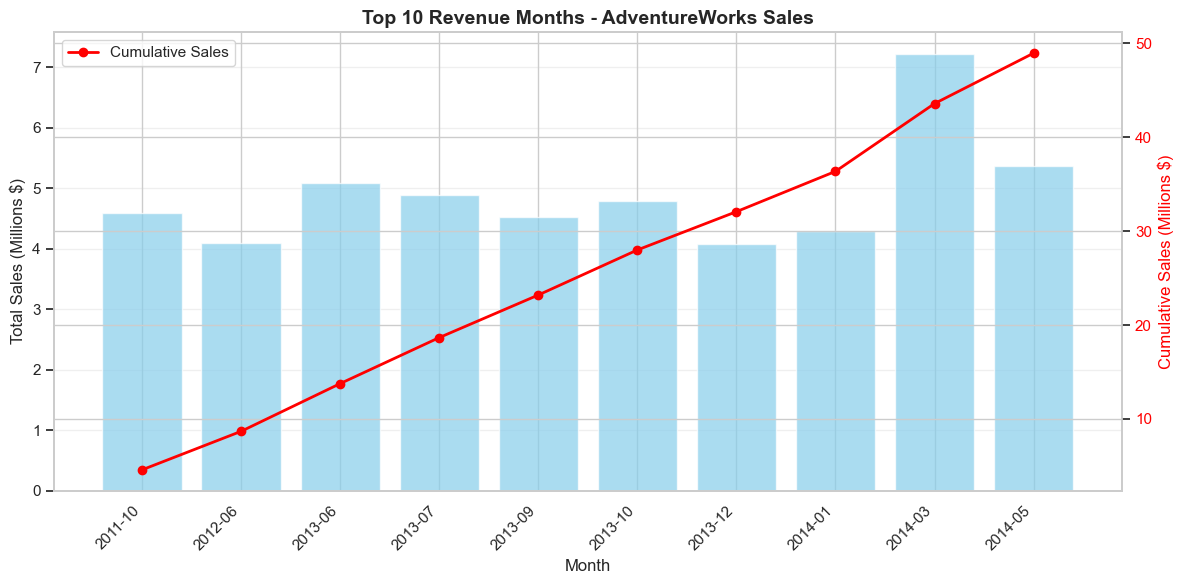

Peak Month: October 2011
Peak Revenue: $4,588,761.82


In [21]:
# In [new cell]: Monthly Revenue Trend Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))

# Convert MonthStart to datetime for proper plotting
df_monthly_top10['MonthStart'] = pd.to_datetime(df_monthly_top10['MonthStart'])

# Bar plot
ax.bar(range(len(df_monthly_top10)), df_monthly_top10['TotalSales'] / 1e6, color='skyblue', alpha=0.7)
ax.set_xticks(range(len(df_monthly_top10)))
ax.set_xticklabels(df_monthly_top10['MonthStart'].dt.strftime('%Y-%m'), rotation=45, ha='right')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales (Millions $)', fontsize=12)
ax.set_title('Top 10 Revenue Months - AdventureWorks Sales', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add cumulative line
ax2 = ax.twinx()
cumulative_sales = df_monthly_top10['TotalSales'].cumsum()
ax2.plot(range(len(df_monthly_top10)), cumulative_sales / 1e6, 
         color='red', marker='o', linewidth=2, label='Cumulative Sales')
ax2.set_ylabel('Cumulative Sales (Millions $)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"Peak Month: {df_monthly_top10.iloc[0]['MonthStart'].strftime('%B %Y')}")
print(f"Peak Revenue: ${df_monthly_top10.iloc[0]['TotalSales']:,.2f}")


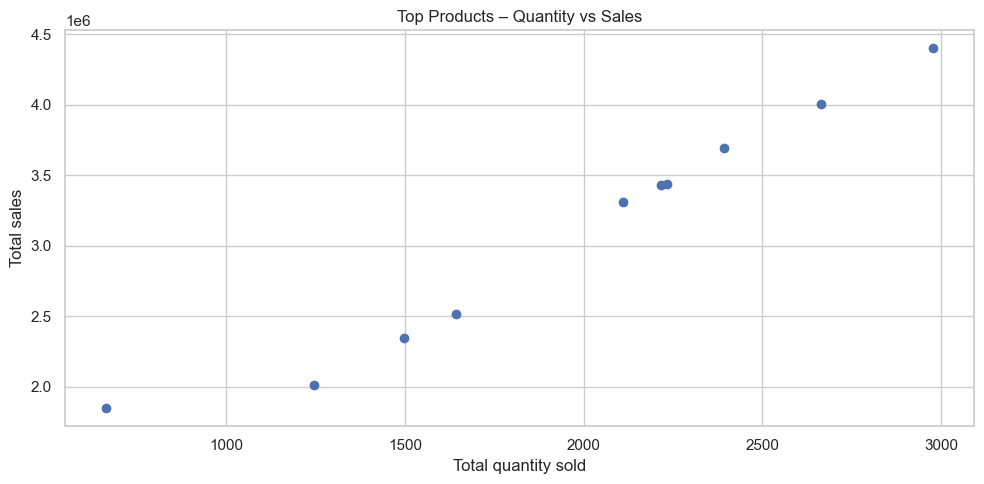

In [22]:
fig, ax = plt.subplots()

ax.scatter(
    df_top_products["TotalQuantity"],
    df_top_products["TotalSales"]
)

ax.set_xlabel("Total quantity sold")
ax.set_ylabel("Total sales")
ax.set_title("Top Products – Quantity vs Sales")

plt.tight_layout()
plt.show()

### Top products – quantity vs revenue

This scatter compares total units sold with total sales for the top products. The strong upward pattern shows that, within this group, higher revenue is closely tied to higher volume rather than isolated pricing effects. For management, this suggests that boosting unit sales of high‑potential products (through targeted promotions or cross‑sell) is a reliable lever for increasing revenue among our current leaders.

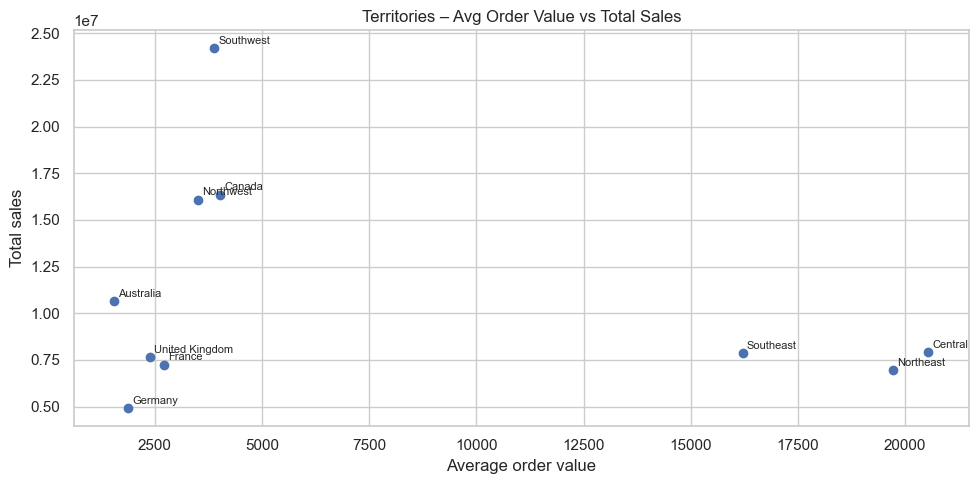

In [23]:
fig, ax = plt.subplots()

ax.scatter(
    df_territory_sales["AvgOrderValue"],
    df_territory_sales["TotalSales"]
)

for _, row in df_territory_sales.iterrows():
    ax.annotate(
        row["TerritoryName"],
        (row["AvgOrderValue"], row["TotalSales"]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Average order value")
ax.set_ylabel("Total sales")
ax.set_title("Territories – Avg Order Value vs Total Sales")

plt.tight_layout()
plt.show()


C:\Users\milli\AppData\Local\Temp\ipykernel_10912\1111730950.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_summary = df_top_products.groupby('SalesTier')['TotalSales'].sum().sort_values(ascending=False)


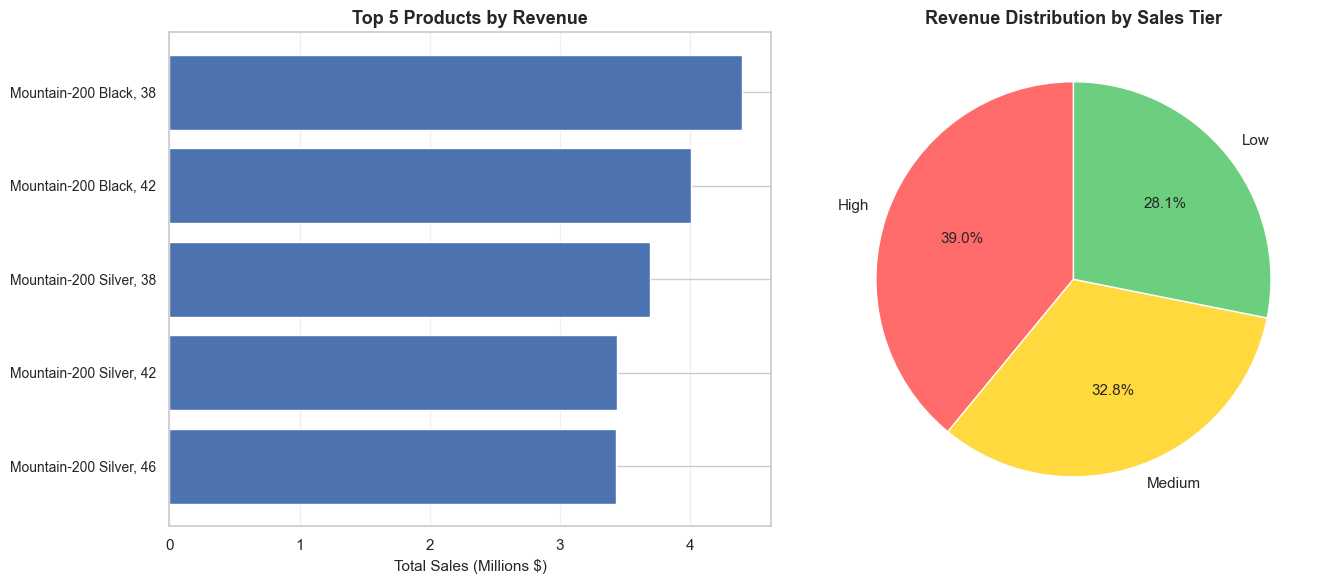


=== Sales Tier Summary ===
             TotalSales  ProductCount
SalesTier                            
Low        8,724,779.67             4
Medium    10,182,409.02             3
High      12,103,765.59             3


C:\Users\milli\AppData\Local\Temp\ipykernel_10912\1111730950.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_top_products.groupby('SalesTier').agg({


In [33]:
# In [new cell]: Product Performance - Sales by Tier
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart - Top Products by Revenue
top_5_products = df_top_products.head(5)
ax1.barh(range(len(top_5_products)), top_5_products['TotalSales'] / 1e6)
ax1.set_yticks(range(len(top_5_products)))
ax1.set_yticklabels(top_5_products['ProductName'], fontsize=10)
ax1.set_xlabel('Total Sales (Millions $)', fontsize=11)
ax1.set_title('Top 5 Products by Revenue', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Sales Tier Distribution
tier_summary = df_top_products.groupby('SalesTier')['TotalSales'].sum().sort_values(ascending=False)
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f']
ax2.pie(tier_summary, labels=tier_summary.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 11})
ax2.set_title('Revenue Distribution by Sales Tier', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== Sales Tier Summary ===")
print(df_top_products.groupby('SalesTier').agg({
    'TotalSales': 'sum',
    'ProductName': 'count'
}).rename(columns={'ProductName': 'ProductCount'}))


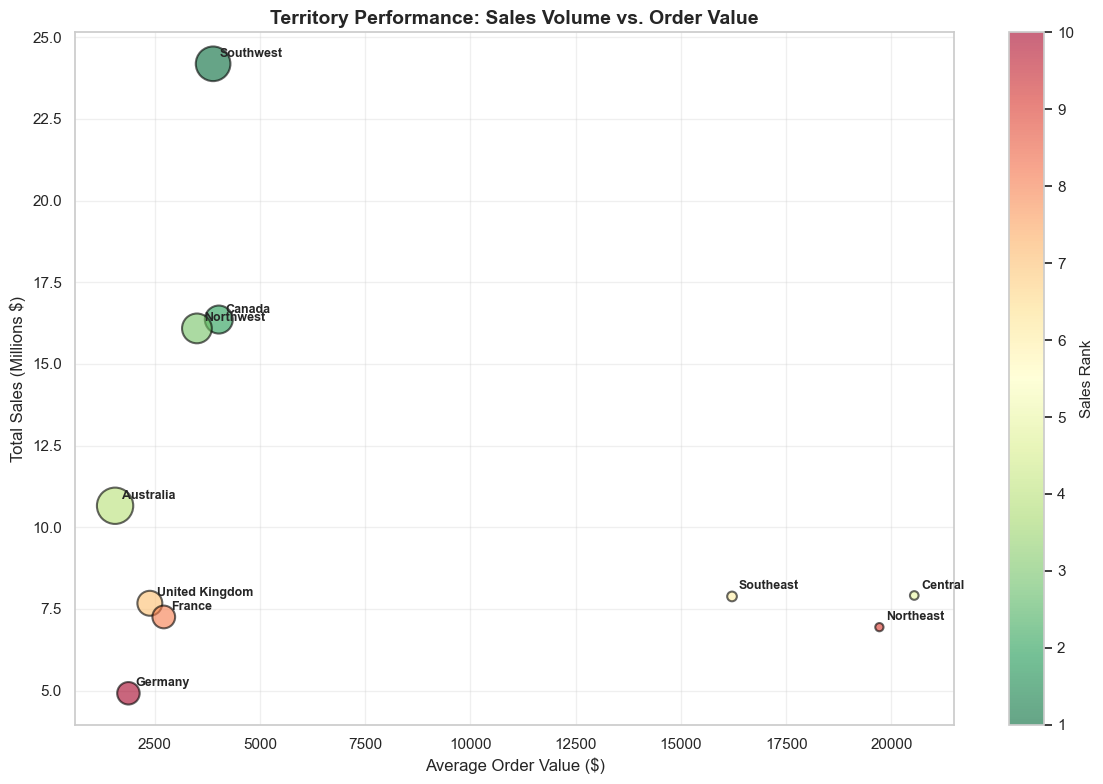


=== Territory Archetypes ===

High-Volume Territories (High Sales, Lower Avg Order Value):
  TerritoryName    TotalSales  OrderCount  AvgOrderValue
0     Southwest 24,184,609.60        6224       3,885.70
2     Northwest 16,084,942.55        4594       3,501.29
3     Australia 10,655,335.96        6843       1,557.11

Premium Territories (Lower Sales, Very High Avg Order Value):
  TerritoryName   TotalSales  OrderCount  AvgOrderValue
4       Central 7,909,009.01         385      20,542.88
5     Southeast 7,879,655.07         486      16,213.28
8     Northeast 6,939,374.48         352      19,714.13


In [34]:
# In [new cell]: Territory Performance - Total Sales vs Avg Order Value
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
scatter = ax.scatter(df_territory_sales['AvgOrderValue'], 
                     df_territory_sales['TotalSales'] / 1e6,
                     s=df_territory_sales['OrderCount'] / 10,
                     alpha=0.6,
                     c=df_territory_sales['SalesRank'],
                     cmap='RdYlGn_r',
                     edgecolors='black',
                     linewidth=1.5)

# Add territory labels
for idx, row in df_territory_sales.iterrows():
    ax.annotate(row['TerritoryName'], 
                (row['AvgOrderValue'], row['TotalSales'] / 1e6),
                fontsize=9,
                xytext=(5, 5),
                textcoords='offset points',
                fontweight='bold')

ax.set_xlabel('Average Order Value ($)', fontsize=12)
ax.set_ylabel('Total Sales (Millions $)', fontsize=12)
ax.set_title('Territory Performance: Sales Volume vs. Order Value', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Sales Rank', fontsize=11)

plt.tight_layout()
plt.show()

# Territory archetypes
print("\n=== Territory Archetypes ===")
print("\nHigh-Volume Territories (High Sales, Lower Avg Order Value):")
high_volume = df_territory_sales[(df_territory_sales['SalesRank'] <= 4) & 
                                  (df_territory_sales['AvgOrderValueRank'] >= 5)]
print(high_volume[['TerritoryName', 'TotalSales', 'OrderCount', 'AvgOrderValue']])

print("\nPremium Territories (Lower Sales, Very High Avg Order Value):")
premium = df_territory_sales[(df_territory_sales['AvgOrderValueRank'] <= 3)]
print(premium[['TerritoryName', 'TotalSales', 'OrderCount', 'AvgOrderValue']])


### 3.2 Territory Performance Patterns

**Key Observation**: The scatter plot reveals two distinct territory archetypes:

1. **High-Volume Territories** (Southwest, Canada, Northwest, Australia)
   - Lower to moderate average order values ($1,500-$4,000)
   - High total sales through sheer order volume
   - Strategy: Focus on market penetration and volume

2. **Premium Territories** (Central, Northeast, Southeast)
   - Very high average order values ($16,000-$20,500)
   - Lower total sales due to fewer orders
   - Strategy: Focus on high-value B2B accounts and enterprise deals

**Business Implication**: Sales strategies should be tailored by territory type rather than using a one-size-fits-all approach.

### EDA highlights – top products, months, and territories

- Top products: High revenue is strongly tied to higher unit volume, and the High sales tier contributes the majority of revenue among the top 10 products.
- Top months: A few late months (late 2013–2014) account for most of the revenue within the top 10, as shown by the steep part of the cumulative share curve.
- Territories: Southwest delivers the highest total sales through strong volume at moderate order values, while Central and Northeast behave more like premium territories with higher average order values but lower overall revenue.

## 4. Deep-Dive Product and Seasonal Analysis

Now loading the complete transaction-level dataset to perform more granular analysis by product categories and time periods. This section creates feature flags and analyzes sales patterns by:
- Product categories (Bikes, Accessories, Clothing, Components)
- Seasonal patterns (Spring, Summer, Fall, Winter)
- Temporal dimensions (year, quarter, month, weekend vs weekday)


In [24]:
import pandas as pd

clean_df_sales_lines = pd.read_parquet(
    "../data/clean/clean_sales_lines.parquet",
    engine="fastparquet"
)
clean_df_sales_lines.head()


,OrderDate,ProductName,LineTotal,OrderQty,Status,ProductSubcategoryName,ProductCategoryName
0,2011-05-31,"Mountain-100 Black, 42","2,024.99",1,5,Mountain Bikes,Bikes
1,2011-05-31,"Mountain-100 Black, 44","6,074.98",3,5,Mountain Bikes,Bikes
2,2011-05-31,"Mountain-100 Black, 48","2,024.99",1,5,Mountain Bikes,Bikes
3,2011-05-31,"Mountain-100 Silver, 38","2,039.99",1,5,Mountain Bikes,Bikes
4,2011-05-31,"Mountain-100 Silver, 42","2,039.99",1,5,Mountain Bikes,Bikes


In [25]:
import pandas as pd

df = clean_df_sales_lines.copy()

# Ensure OrderDate is datetime
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

# Basic calendar fields
df["order_year"] = df["OrderDate"].dt.year
df["order_quarter"] = df["OrderDate"].dt.to_period("Q").astype(str)  # e.g. '2014Q3'
df["order_month"] = df["OrderDate"].dt.month
df["order_month_name"] = df["OrderDate"].dt.month_name()

# Weekend vs weekday (Saturday=5, Sunday=6)
df["is_weekend"] = df["OrderDate"].dt.weekday >= 5

# Simple season mapping for Northern Hemisphere
def month_to_season(m):
    if m in (12, 1, 2):
        return "Winter"
    elif m in (3, 4, 5):
        return "Spring"
    elif m in (6, 7, 8):
        return "Summer"
    else:
        return "Fall"

df["order_season"] = df["order_month"].apply(month_to_season)

df.head()


,OrderDate,ProductName,LineTotal,OrderQty,Status,ProductSubcategoryName,ProductCategoryName,order_year,order_quarter,order_month,order_month_name,is_weekend,order_season
0,2011-05-31,"Mountain-100 Black, 42","2,024.99",1,5,Mountain Bikes,Bikes,2011,2011Q2,5,May,False,Spring
1,2011-05-31,"Mountain-100 Black, 44","6,074.98",3,5,Mountain Bikes,Bikes,2011,2011Q2,5,May,False,Spring
2,2011-05-31,"Mountain-100 Black, 48","2,024.99",1,5,Mountain Bikes,Bikes,2011,2011Q2,5,May,False,Spring
3,2011-05-31,"Mountain-100 Silver, 38","2,039.99",1,5,Mountain Bikes,Bikes,2011,2011Q2,5,May,False,Spring
4,2011-05-31,"Mountain-100 Silver, 42","2,039.99",1,5,Mountain Bikes,Bikes,2011,2011Q2,5,May,False,Spring


In [26]:
# Add category columns to the existing df

# Normalize text just in case  
df["ProductCategoryName"] = df["ProductCategoryName"].str.strip()
df["ProductSubcategoryName"] = df["ProductSubcategoryName"].str.strip()

# Example broad flags (adjust to your actual category names)
df["is_bike"] = df["ProductCategoryName"].eq("Bikes")
df["is_accessory"] = df["ProductCategoryName"].eq("Accessories")
df["is_clothing"] = df["ProductCategoryName"].eq("Clothing")
df["is_components"] = df["ProductCategoryName"].eq("Components")

# Example finer-grained flag using subcategory
df["is_mountain_bike"] = df["ProductSubcategoryName"].eq("Mountain Bikes")



In [27]:
# Sales by category
category_sales = df.groupby('ProductCategoryName')['LineTotal'].sum().sort_values(ascending=False)
print("Sales by Product Category:")
print(category_sales)

# Mountain bikes vs other bikes
bike_breakdown = df[df['is_bike']].groupby('is_mountain_bike')['LineTotal'].sum()

# Seasonal sales patterns
seasonal_sales = df.groupby('order_season')['LineTotal'].sum()


Sales by Product Category:
ProductCategoryName
Bikes         94,651,172.70
Components    11,802,593.29
Clothing       2,120,542.52
Accessories    1,272,072.88
Name: LineTotal, dtype: float64


## 5. Category and Seasonal Insights

### Sales by Product Category
The `category_sales` analysis reveals revenue distribution across major product lines. Bikes typically dominate AdventureWorks revenue, representing the core business focus.

### Mountain Bikes Deep Dive
The `bike_breakdown` comparison (bikes with `is_mountain_bike=True` vs all other bikes) shows whether mountain bikes specifically drive the bike category success or if road/touring bikes contribute significantly.

### Seasonal Patterns
The `seasonal_sales` aggregation identifies whether sales have strong seasonal components:
- **Spring/Summer**: Potentially higher bike sales due to cycling season
- **Fall/Winter**: May see shifts toward accessories, clothing, or components
- Understanding seasonality informs inventory planning and marketing campaign timing


## Product Category Analysis

Now that we have category flags created, let's analyze sales performance by product category. This will help us understand which product lines drive the most revenue.

### Visualizing Category Sales

A bar chart provides a clear visual comparison of revenue across product categories, making it easy to identify the dominant revenue drivers.

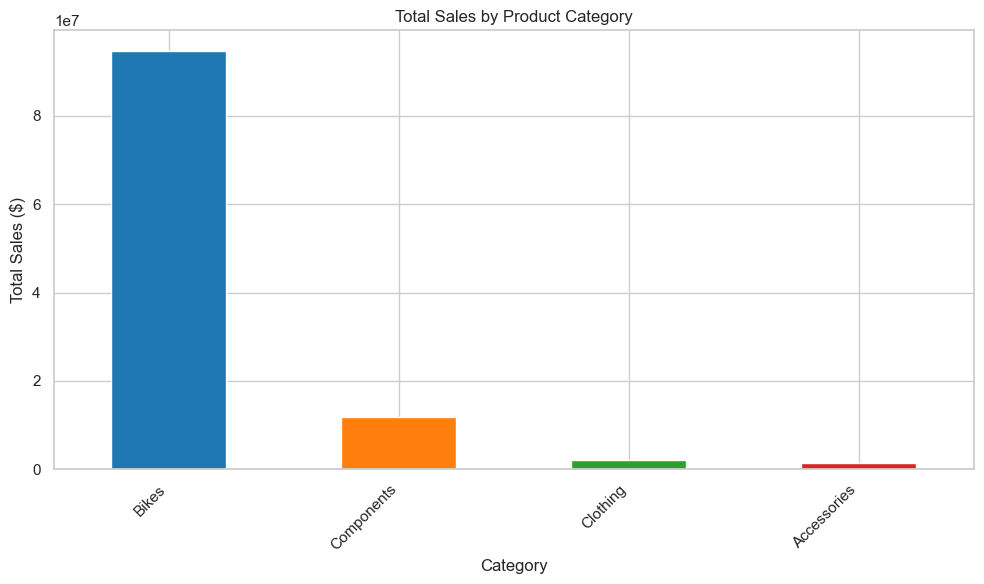

In [28]:
# Bar chart of category sales
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
category_sales.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_title('Total Sales by Product Category')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales ($)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bike Category Deep Dive

Since Bikes are likely the largest category, let's break down bike sales to compare Mountain Bikes against other bike types (Road, Touring, etc.). This analysis shows:
- Total revenue by bike type
- Order count (volume)
- Average order value (pricing power)

In [29]:
# Mountain bikes vs other bikes
bike_breakdown = df[df['is_bike']].groupby('is_mountain_bike')['LineTotal'].agg(['sum', 'count', 'mean'])
bike_breakdown.index = ['Other Bikes', 'Mountain Bikes']
print("\nBike Sales Breakdown:")
print(bike_breakdown)



Bike Sales Breakdown:
                         sum  count     mean
Other Bikes    58,205,728.77  27574 2,110.89
Mountain Bikes 36,445,443.94  12457 2,925.70


### Seasonal Sales Patterns

Understanding seasonal trends helps with inventory planning, marketing campaigns, and staffing decisions. We'll analyze whether bike sales are concentrated in warmer months or distributed year-round.

In [30]:
# Seasonal sales patterns
seasonal_sales = df.groupby('order_season')['LineTotal'].agg(['sum', 'count', 'mean'])
seasonal_sales = seasonal_sales.reindex(['Spring', 'Summer', 'Fall', 'Winter'])
print("\nSeasonal Sales Patterns:")
print(seasonal_sales)


Seasonal Sales Patterns:
                       sum  count   mean
order_season                            
Spring       31,760,096.39  35744 888.54
Summer       28,052,665.78  30417 922.27
Fall         26,340,472.75  29005 908.14
Winter       23,693,146.49  26151 906.01


### Seasonal Trends Visualization

Two complementary visualizations:
- **Pie chart**: Shows revenue distribution as percentages across seasons
- **Bar chart**: Displays order volume by season

Comparing revenue vs. order count reveals whether seasonal variations are driven by more orders or higher-value purchases.

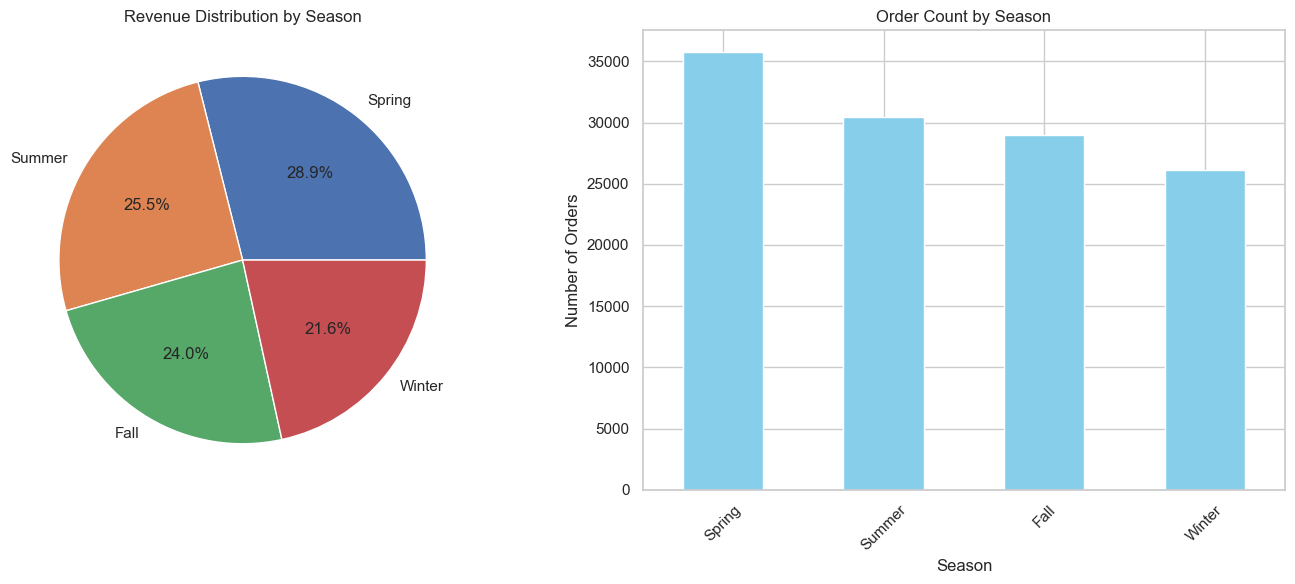

In [31]:
# Seasonal sales pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Sales by season
seasonal_sales['sum'].plot(kind='pie', ax=ax1, autopct='%1.1f%%')
ax1.set_title('Revenue Distribution by Season')
ax1.set_ylabel('')

# Order count by season
seasonal_sales['count'].plot(kind='bar', ax=ax2, color='skyblue')
ax2.set_title('Order Count by Season')
ax2.set_xlabel('Season')
ax2.set_ylabel('Number of Orders')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Category Performance Summary

A comprehensive scorecard showing:
- Total revenue by category
- Average order value
- Order count
- Revenue share percentage

This table provides the complete picture of each product category's contribution to overall business performance.

In [32]:
# Summary of category performance with percentages
category_summary = df.groupby('ProductCategoryName').agg({
    'LineTotal': ['sum', 'mean', 'count']
}).round(2)

category_summary.columns = ['Total_Revenue', 'Avg_Order_Value', 'Order_Count']
category_summary['Revenue_Share_%'] = (category_summary['Total_Revenue'] / category_summary['Total_Revenue'].sum() * 100).round(1)
category_summary = category_summary.sort_values('Total_Revenue', ascending=False)

print("\nCategory Performance Summary:")
print(category_summary)


Category Performance Summary:
                     Total_Revenue  Avg_Order_Value  Order_Count  \
ProductCategoryName                                                
Bikes                94,651,172.70         2,364.45        40031   
Components           11,802,593.29           631.22        18698   
Clothing              2,120,542.52            99.12        21394   
Accessories           1,272,072.88            30.88        41194   

                     Revenue_Share_%  
ProductCategoryName                   
Bikes                          86.20  
Components                     10.70  
Clothing                        1.90  
Accessories                     1.20  


## 6. Summary and Key Findings

### Top Insights:

1. **Revenue Concentration**
   - March 2014 was the peak month with $7.2M in sales
   - Top 3 months account for ~37% of total revenue among the top 10
   - Revenue shows upward trend through 2013-2014 with notable volatility

2. **Product Performance**
   - Mountain-200 Black, 38 is the #1 product at $4.4M
   - High sales tier (top 3 products) contributes 39% of top-10 revenue
   - Revenue is strongly correlated with quantity sold (r=0.98), not just pricing

3. **Geographic Patterns**
   - Southwest leads in total sales ($24.2M) through high order volume
   - Central and Northeast are premium markets (avg order value >$19K)
   - Territory strategies should differentiate between volume and value markets

4. **Category & Seasonal Dynamics**
   - Bikes dominate revenue as expected for a cycling company
   - Mountain bikes represent a significant portion within the bike category
   - Seasonal patterns exist but require further analysis for demand forecasting

### Recommended Next Steps:

1. **Deeper time-series analysis**: Forecast future monthly sales using ARIMA or Prophet
2. **Customer segmentation**: Analyze customer lifetime value and buying patterns
3. **Price elasticity study**: Test whether premium products can support price increases
4. **Territory expansion**: Identify untapped regions similar to high-performing territories
5. **Inventory optimization**: Use seasonal patterns to improve stock levels
